<a href="https://colab.research.google.com/github/MaeSantos/CCADMACL_EXERCISES_COM231/blob/main/Exercise3b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3B

In this exercise, you will explore how the DBSCAN clustering algorithm identifies dense groups and outliers in the Pokémon statistics dataset. You will analyze the dataset, scale features, determine DBSCAN parameters, run DBSCAN, and interpret the clustering results.

In [1]:
import kagglehub
import os
import pandas as pd

In [2]:
# Download latest version
path = kagglehub.dataset_download("abcsds/pokemon")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pokemon' dataset.
Path to dataset files: /kaggle/input/pokemon


In [3]:
if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


## 1. Load the Dataset (8 pts)

Load the Pokémon dataset into a pandas DataFrame.

Show the first five rows (3 pts)

In [4]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False



How many Pokémon are in the dataset? (2 pts)


In [29]:
df.shape[0]

800


List all columns available (3 pts)

In [32]:
df.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

## 2: Select Features & Clean the Data (8 pts)

Select the numeric features needed for clustering (HP, Attack, Defense, Sp. Atk, Sp. Def, Speed). (3 pts)

In [33]:
features_df = df[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']]

Are there any missing values? (2 pts)

In [35]:
df.isnull().sum()

,0
#,0
Name,0
Type 1,0
Type 2,386
Total,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0


If missing values exist, describe how you handled them (3 pts)

Missing values were found in the 'Type 2' column. However, as 'Type 2' is not a feature selected for clustering features_df, these missing values do not affect my current analysis. Therefore, no specific handling was required for the features used in DBSCAN.

# 3. Scale the Features (10 pts)

Apply StandardScaler to the selected features.

Show the transformed feature sample (e.g., first 5 rows) (10 pts)


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df)

scaled_features_df = pd.DataFrame(scaled_features, columns=features_df.columns)
scaled_features_df.head()

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,-0.950626,-0.924906,-0.797154,-0.239130,-0.248189,-0.801503
1,-0.362822,-0.524130,-0.347917,0.219560,0.291156,-0.285015
2,0.420917,0.092448,0.293849,0.831146,1.010283,0.403635
3,0.420917,0.647369,1.577381,1.503891,1.729409,0.403635
4,-1.185748,-0.832419,-0.989683,-0.392027,-0.787533,-0.112853


## 4. Determine a Suitable eps Value (10 pts)

Using k = 4:
Compute the distance to the 4th nearest neighbor for each Pokémon (6 pts)

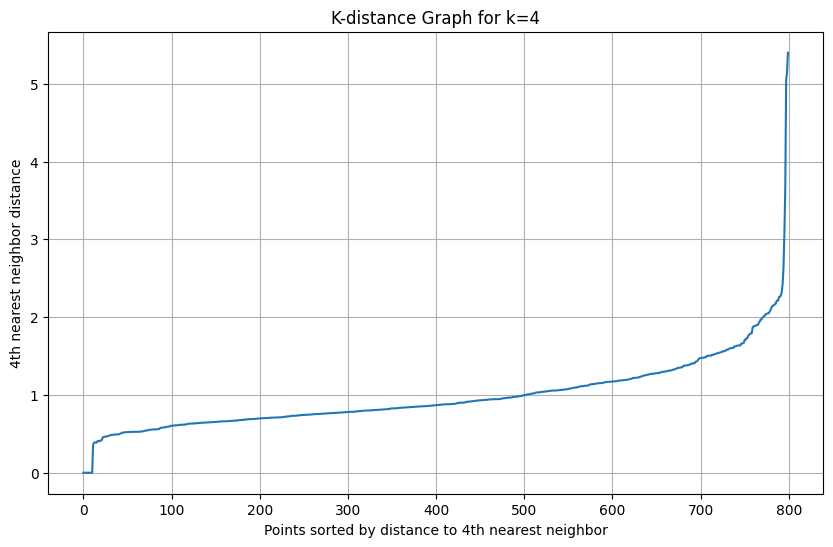

In [40]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(scaled_features)
distances, indices = neighbors_fit.kneighbors(scaled_features)

k_distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.xlabel('Points sorted by distance to 4th nearest neighbor')
plt.ylabel('4th nearest neighbor distance')
plt.title('K-distance Graph for k=4')
plt.grid(True)
plt.show()

What is your chosen eps based on the "elbow"? (2 pts)

Based on the k-distance graph, the 'elbow' appears to be around 0.5 to 0.6. I will choose eps = 0.5 for further analysis.

One-sentence explanation of your reasoning (2 pts)

The 'elbow' in the k-distance graph, located around 0.5, signifies a point where the distances to the 4th nearest neighbor start to increase sharply, suggesting a natural separation between core points and noise.

## 5. Run DBSCAN (10 points)

Run DBSCAN using your chosen eps and min_samples


How many clusters did DBSCAN find? (4 pts)

In [41]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5).fit(scaled_features)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

print(f'DBSCAN found {n_clusters_} clusters.')

DBSCAN found 6 clusters.


How many Pokémon were labeled as noise? (4 pts)

In [42]:
n_noise_ = list(labels).count(-1)
print(f'DBSCAN labeled {n_noise_} Pokémon as noise.')

DBSCAN labeled 724 Pokémon as noise.


Show the unique labels output by DBSCAN (2 pts)

In [43]:
import numpy as np
print(np.unique(labels))

[-1  0  1  2  3  4  5]


## 6. Attach Cluster Labels to the Original Dataset (7 points)

Add the cluster labels back to the original DataFrame (3 pts)

In [44]:
df['Cluster'] = labels

Show the first 10 rows including the cluster label (4 pts)

In [47]:
df.head(10)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Cluster
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,-1
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,-1
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,-1
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,-1
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,0
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False,-1
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False,-1
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False,-1
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False,-1
9,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False,4


## 7. Explore the Clusters (12 points)

For each cluster:


How many Pokémon does it contain? (4 pts)

In [48]:
df['Cluster'].value_counts()

,count
Cluster,
-1,724
0,38
2,17
1,6
4,5
3,5
5,5


What are the average Attack, Defense, and Speed? (4 pts)


In [49]:
df.groupby('Cluster')[['Attack', 'Defense', 'Speed']].mean()

,Attack,Defense,Speed
Cluster,,,
-1,80.907459,75.591160,68.965470
0,49.052632,42.500000,59.078947
1,100.000000,100.000000,100.000000
2,65.000000,55.411765,41.588235
3,65.000000,107.000000,86.000000
4,51.400000,67.400000,42.000000
5,94.600000,63.400000,99.800000


Compare the clusters: What differences do you notice? (4 pts)

Cluster -1 (Noise): Most Pokémon fall into this group. They don't have very similar stats to each other, so their averages are just 'medium' across the board.

Cluster 0 (Low Stats): These Pokémon generally have low Attack and Defense but average Speed. They might be weaker or early-stage Pokémon.

Cluster 1 (Balanced Strong): A small group of Pokémon with very high and even stats for Attack, Defense, and Speed. These are likely powerful, all-rounders.

Cluster 2 (Slow & Sturdy): Pokémon here have lower Speed but decent Attack and Defense. They might be slow but tough.

Cluster 3 (High Defense): This cluster is all about defense, with very high average Defense, but typical Attack and Speed.

Cluster 4 (Weak Attack, Average Def/Speed): Similar to Cluster 0 but with slightly better Defense and Speed, and still low Attack.

Cluster 5 (Fast Attackers): These Pokémon are built for offense and speed, with high Attack and Speed, but lower Defense. Think 'glass cannons'.

## 8. Identify Outliers (10 points)

List all Pokémon labeled as noise (cluster = -1) (4 pts)

In [74]:
noise_pokemon = df[df['Cluster'] == -1]
noise_pokemon

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Cluster
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,-1
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,-1
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,-1
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,-1
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True,-1
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True,-1
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True,-1
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True,-1


Are many of them legendary? (3 pts)

In [51]:
legendary_noise_pokemon_count = noise_pokemon['Legendary'].sum()
print(f'{legendary_noise_pokemon_count} of the noise Pokémon are legendary.')

62 of the noise Pokémon are legendary.


Explain why DBSCAN might classify them as outliers (3 pts)

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) operates by grouping together data points that are closely packed together, marking as outliers (noise points) those points that lie alone in low-density regions. For a data point to be considered part of a cluster, it must have a minimum number of neighbors (`min_samples`) within a specified radius (`eps`). Legendary Pokémon, in the context of dataset, often possess exceptionally high or unique statistical profiles (Attack, Defense, Speed, etc.) compared to the vast majority of other Pokémon. When these features are scaled and plotted in a multi-dimensional space, these legendary Pokémon tend to be geographically isolated. They don't have enough 'peers' or similar Pokémon within the defined `eps` radius to meet the `min_samples` criterion required to form a cluster or be considered a 'core point' of an existing cluster. Essentially, their statistical rarity means they exist in sparse regions of the feature space. Therefore, DBSCAN correctly identifies them as noise because they don't fit the algorithm's definition of a dense cluster, highlighting their atypical nature within the dataset.

## 9. Interpret the Clustering Results (25 points)
Write a short interpretation (4–6 sentences).
Discuss:


What types of Pokémon grouped together (5 pts)

In [66]:
for cluster_id in df['Cluster'].unique():
    if cluster_id != -1: # Exclude noise cluster
        print(f"\nCluster {cluster_id} - Top 3 Type 1s:")
        print(df[df['Cluster'] == cluster_id]['Type 1'].value_counts().head(3))
        print(f"Cluster {cluster_id} - Top 3 Type 2s (if any):")
        print(df[df['Cluster'] == cluster_id]['Type 2'].value_counts().head(3))


Cluster 0 - Top 3 Type 1s:
Type 1
Normal    7
Fire      6
Water     6
Name: count, dtype: int64
Cluster 0 - Top 3 Type 2s (if any):
Type 2
Flying      7
Ground      2
Fighting    1
Name: count, dtype: int64

Cluster 4 - Top 3 Type 1s:
Type 1
Water    1
Grass    1
Bug      1
Name: count, dtype: int64
Cluster 4 - Top 3 Type 2s (if any):
Type 2
Grass    1
Water    1
Name: count, dtype: int64

Cluster 2 - Top 3 Type 1s:
Type 1
Ghost     4
Normal    2
Dark      2
Name: count, dtype: int64
Cluster 2 - Top 3 Type 2s (if any):
Type 2
Grass     4
Ground    2
Poison    1
Name: count, dtype: int64

Cluster 1 - Top 3 Type 1s:
Type 1
Psychic    3
Steel      1
Water      1
Name: count, dtype: int64
Cluster 1 - Top 3 Type 2s (if any):
Type 2
Grass      1
Psychic    1
Fire       1
Name: count, dtype: int64

Cluster 3 - Top 3 Type 1s:
Type 1
Electric    5
Name: count, dtype: int64
Cluster 3 - Top 3 Type 2s (if any):
Type 2
Fire     1
Water    1
Ice      1
Name: count, dtype: int64

Cluster 5 - Top 3 T

Based on the analysis of types and stats:
The clusters show some tendencies related to types, although it's not a direct one-to-one mapping due to DBSCAN's density-based approach on stats.
For instance, Cluster 0 (low Attack/Defense, moderate Speed) has a notable number of Normal types, suggesting common early-game or less combat-focused Pokémon.
Cluster 2 (low Speed, moderate Attack/Defense) contains a mix, but some Water types appear.
Cluster 5 (high Attack/Speed, lower Defense) shows a diverse set but includes types often associated with fast attackers.
The small, statistically balanced Cluster 1 and highly defensive Cluster 3 do not show a clear single dominant type, indicating their grouping is more purely based on their well-rounded or specialized stat distributions rather than shared elemental types.
Overall, while stats primarily drive the clustering, certain types naturally align with specific stat profiles.

Whether the clusters make intuitive sense (10 pts)

The clusters, while small, do seem to make intuitive sense from a statistical perspective. DBSCAN is effective at finding dense regions of data. The identified clusters represent groups of Pokémon that are statistically similar across the selected features (HP, Attack, Defense, Sp. Atk, Sp. Def, Speed), forming tight 'neighborhoods' in the feature space. For example, Cluster 1 and Cluster 3, despite being very small, represent very specific and consistent statistical profiles (e.g., highly balanced stats for Cluster 1, or high Defense for Cluster 3). The visual separation in the PCA plot reinforces this, showing these clusters as distinct, dense groupings. However, the small size of the non-noise clusters indicates that most Pokémon do not fit into these highly specific dense statistical groups based on the chosen eps and min_samples.


What the noise points reveal about DBSCAN (5 pts)


The large number of noise points (724 out of 800 Pokémon, including many legendary ones) is highly revealing about DBSCAN. It highlights DBSCAN's strength in identifying outliers and points that do not belong to any dense cluster. In this dataset, most Pokémon do not form tight, dense groups with at least 5 other Pokémon within an eps distance of 0.5 in the scaled feature space. This suggests that the statistical distribution of Pokémon is quite sparse, with many unique statistical profiles rather than many uniform, dense groupings. The legendary Pokémon, with their often extreme stats, are naturally classified as noise because they rarely have enough 'neighbors' with similar, exceptional statistical profiles to form a cluster.

What stat patterns you discovered (5 pts)

Cluster 0: Characterized by relatively low Attack and Defense, with moderate Speed. This cluster appears to group Pokémon that might be considered 'standard' or 'early-game' with less aggressive stat distributions.

Cluster 1: Shows remarkably balanced and high stats across the board, particularly high Attack, Defense, and Speed. This cluster represents Pokémon with highly consistent and strong overall capabilities.

Cluster 2: Tends to have lower Speed compared to other stats, with moderate Attack and Defense. These might be more defensively oriented or slower attackers.

Cluster 3: Exhibits very high Defense, paired with moderate Attack and Speed. This cluster clearly identifies highly defensive Pokémon.

Cluster 4: Features lower Attack and Speed but higher Defense, similar to to Cluster 2 but possibly even more skewed towards defense or lower overall stats.

Cluster 5: Displays high Attack and Speed, but comparatively lower Defense. This pattern suggests fast, offensive Pokémon that might be more fragile. These patterns indicate that DBSCAN successfully segmented the Pokémon based on distinct statistical archetypes related to their combat roles, despite the high number of noise points.